# Byte-Pair Encoding:

The original BPE algorithm operates by iteratively replacing the most common contiguous sequences of characters in a target text with unused 'placeholder' bytes. The iteration ends when no sequences can be found, leaving the target text effectively compressed. Decompression can be performed by reversing this process, querying known placeholder terms against their corresponding denoted sequence, using a lookup table. In the original paper, this lookup table is encoded and stored alongside the compressed text.

Example
Suppose the data to be encoded is:

aaabdaaabac

The byte pair "aa" occurs most often, so it will be replaced by a byte that is not used in the data, such as "Z". Now there is the following data and replacement table:

ZabdZabac
Z=aa

Then the process is repeated with byte pair "ab", replacing it with "Y":

ZYdZYac

Y=ab
Z=aa

The only literal byte pair left occurs only once, and the encoding might stop here. Alternatively, the process could continue with recursive byte-pair encoding, replacing "ZY" with "X":

XdXac

X=ZY
Y=ab
Z=aa

This data cannot be compressed further by byte-pair encoding because there are no pairs of bytes that occur more than once.

To decompress the data, simply perform the replacements in the reverse order.

In [12]:
text="The original BPE algorithm operates by iteratively replacing the most common contiguous sequences of characters in a target text with unused 'placeholder' bytes. The iteration ends when no sequences can be found, leaving the target text effectively compressed. Decompression can be performed by reversing this process, querying known placeholder terms against their corresponding denoted sequence, using a lookup table. In the original paper, this lookup table is encoded and stored alongside the compressed text."
token=text.encode("utf-8")
tokens=list(map(int,token))
print("Length of Text:",len(text))
print("Number of Tokens:",len(tokens))

Length of Text: 513
Number of Tokens: 513


### Mapping Consecutive elements:

In [34]:
def map_ele(ids):
    count={}
    for pair in zip(ids,ids[1:]):
        count[pair]=count.get(pair,0)+1
    return count

data=map_ele(tokens)
max_time_eles=sorted(((v,k) for k, v in data.items()),reverse=True)
print(max_time_eles)

[(15, (32, 116)), (11, (101, 114)), (10, (116, 101)), (10, (115, 32)), (10, (105, 110)), (10, (101, 32)), (9, (116, 104)), (9, (110, 32)), (9, (101, 115)), (8, (104, 101)), (8, (32, 99)), (7, (114, 101)), (7, (110, 103)), (7, (101, 110)), (7, (101, 100)), (7, (100, 32)), (7, (99, 111)), (6, (116, 32)), (6, (115, 101)), (6, (111, 114)), (6, (111, 110)), (6, (103, 32)), (6, (99, 101)), (6, (32, 97)), (5, (100, 101)), (5, (32, 98)), (4, (121, 32)), (4, (117, 101)), (4, (116, 105)), (4, (116, 97)), (4, (115, 115)), (4, (115, 105)), (4, (114, 97)), (4, (113, 117)), (4, (112, 114)), (4, (111, 109)), (4, (110, 100)), (4, (110, 99)), (4, (105, 116)), (4, (97, 108)), (4, (97, 99)), (4, (44, 32)), (4, (32, 115)), (4, (32, 112)), (4, (32, 111)), (4, (32, 105)), (3, (120, 116)), (3, (118, 101)), (3, (117, 115)), (3, (115, 116)), (3, (114, 105)), (3, (112, 108)), (3, (112, 101)), (3, (110, 111)), (3, (109, 112)), (3, (108, 111)), (3, (108, 101)), (3, (108, 97)), (3, (105, 115)), (3, (105, 103)), (3

### Replacing the max consecutive element with new IDX:

In [ ]:
max_idx=max(data, key=data.get)
def rep_idx(ids,pair,idx):
    newidx=[]
    i=0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            newidx.append(idx)
            i+=2
        else:
            newidx.append(ids[i])
            i+=1
    return newidx

indexes=rep_idx(tokens,max_idx,256)
print(f"Maximum times repeated element:{chr(max_idx[0]),chr(max_idx[1])} and times:{max_time_eles[0][0]}")
print("Number of Tokens before replacement(Byte pair):",len(tokens))
print("Number of Tokens after replacement(Byte pair):",len(indexes))

Maximum times repeated element:(' ', 't') and times:15
Number of Tokens before replacement(Byte pair): 513
Number of Tokens after replacement(Byte pair): 498


### Merging loop:

In [ ]:
textt = "Vellore Institute of Technology or VIT is a private deemed university[2][3] in Vellore, Tamil Nadu, India. The institution offers undergraduate and postgraduate programmes.[4] It has campuses in Vellore and Chennai and three sister universities as distinct state private universities in Amaravati,[5] Bhopal,[6] Bengaluru[7] in India and an international campus in Mauritius.[8] History: VIT was established under Section 3 of the University Grants Commission Act, 1956, and was founded in 1984 by G. Viswanathan as a self-financing institution called the Vellore Engineering College. In 2001, it became a deemed university.[9] In September 2006, it was renamed to VIT University. What truly sets VIT apart is its student-centric approach, including the Fully Flexible Credit System (FFCS), allowing students to choose their courses, faculty, and class schedules, combined with a strong research ecosystem and global partnerships that have helped VIT consistently rank among the top private universities in India and gain recognition in QS and Times Higher Education global rankings. Academics and Research: 70+ undergraduate, 50+ postgraduate, and 10+ integrated programs across engineering, science, business, law, design, and humanities; organized into 15+ specialized schools like SCOPE (Computer Science), SMEC (Mechanical), SBST (Biosciences), and VITBS (Business School), each with dedicated labs, faculty, and research centers; 10+ advanced research centers including the Centre for Nanotechnology Research, Automotive Research Centre, and Bio-Medical Research Centre; ₹100+ crore funding from ISRO, DST, DRDO, and international bodies with 50+ ongoing projects; active student chapters including IEEE, ACM, ASME, AIESEC, SAE International, IEEE WIE, CSED, CompBio Cell, and BRSI; diverse student teams in SAE, robotics, aero and space, hackathons, and coding competitions. Rankings: ARWU (2022) 601–700; QS World (2025) 791–800; QS Asia (2023) 173; Times World (2023) 801–1000; Times Asia (2022) 251–300; Times Emerging (2022) 301–350; NIRF Overall (2024) 19; NIRF Research (2024) 13; NIRF Universities (2024) 10; NIRF Engineering (2024) 11; Outlook India (2022) 1 among private colleges; QS World (2026) 691; India Today (2020) 20 among engineering colleges. Accreditation: A++ grade by NAAC (4 cycles), preparing for third NBA accreditation, accredited by ABET, ACBSP (VIT Business School), and ACCA (BBA program). Cultural Festivals: Riviera – VIT Vellore, an international sports and cultural festival with 45,000+ participants from 26 countries, ISO certified and Guinness World Record holder; Vibrance – VIT Chennai, a four-day cultural and sports festival with 22,000+ students. Controversies: In October 2013, two female students were suspended after organizing an online survey on safety and inequality; an American professor was reportedly fired for supporting them; in March 2024, an athletic event faced backlash for different race distances for men and women, and the poster was later redesigned."
text_tokens=textt.encode("utf-8")

def map_ele(ids): # Returns A mapping of Elements (How many times a particular consecutive elements repeat):
    count={}
    for pair in zip(ids,ids[1:]):
        count[pair]=count.get(pair,0)+1
    return count

def rep_idx(ids,pair,idx): # Returns a new token list with repeated elements bunched together:
    newidx=[]
    i=0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            newidx.append(idx)
            i+=2
        else:
            newidx.append(ids[i])
            i+=1
    return newidx

vocab_size=276 # we Want our Vocab list to be og 276 tokens only
num_ranges=vocab_size-256
ids=list(text_tokens)
original_length=len(ids)

merges={}
for i in range(num_ranges): #Making a Merging table kind of thing:
    stats=map_ele(ids)
    pair=max(stats,key=stats.get)
    idx=256+i
    print(f"merging: {pair} with index : {idx}")
    ids=rep_idx(ids,pair,idx)
    merges[pair]=idx

Final_length=len(ids)

print("Original length:",original_length)
print("Final length:",Final_length)
print("Compression ratio:", Final_length / original_length)
print("Final vocabulary size:", 256 + len(merges))

merging: (32, 97) with index : 256
merging: (105, 110) with index : 257
merging: (100, 32) with index : 258
merging: (101, 114) with index : 259
merging: (101, 115) with index : 260
merging: (44, 32) with index : 261
merging: (101, 32) with index : 262
merging: (116, 105) with index : 263
merging: (256, 110) with index : 264
merging: (115, 32) with index : 265
merging: (101, 110) with index : 266
merging: (111, 114) with index : 267
merging: (264, 258) with index : 268
merging: (111, 110) with index : 269
merging: (97, 108) with index : 270
merging: (99, 104) with index : 271
merging: (116, 104) with index : 272
merging: (50, 48) with index : 273
merging: (115, 116) with index : 274
merging: (257, 103) with index : 275
Original length: 3034
Final length: 2430
Compression ratio: 0.8009228740936059
Final vocabulary size: 276


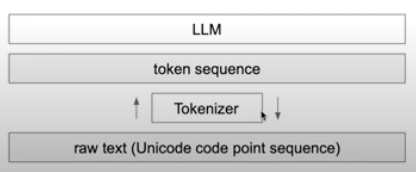

### **Encoding and Decoding:**

In [59]:
vocab={idx:bytes([idx]) for idx in range(256)}
for (p0,p1),idx in merges.items():
    vocab[idx]=vocab[p0]+vocab[p1]

# Decoding:
def decoding(ids):
    tokens=b"".join(vocab[idx] for idx in ids)
    decoded_txt=tokens.decode("utf-8",errors="replace")
    return decoded_txt

#Encoding:
def encoding(text):
    tokens=list(text.encode("utf-8"))
    while True:
        stats=map_ele(tokens)
        pair=min(stats,key=lambda p:merges.get(p,float("inf")))
        if pair not in merges:
            break
        idx=merges[pair]
        tokens=rep_idx(tokens,pair,idx)
    return tokens

print(encoding("Hello world")) 
print(decoding([72, 101, 108, 108, 111, 32, 119, 267, 108, 100]))


[72, 101, 108, 108, 111, 32, 119, 267, 108, 100]
Hello world


### Forced split using Regex Pattern(GPT Style):

In [1]:
import regex as re
gpt2pat=re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")
print(re.findall(gpt2pat,"How are you?"))

['How', ' are', ' you', '?']


### TikToken Usage:

In [ ]:
import tiktoken

#Inference Mode:
enc=tiktoken.get_encoding("gpt2")
print(enc.encode("    Hello world"))

enc=tiktoken.get_encoding("cl100k_base")
print(enc.encode("    Hello world"))

[220, 220, 220, 18435, 995]
[262, 22691, 1917]


### Using GPT's Tokenizer:

Invoke-WebRequest -Uri "https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe" -OutFile "vocab.bpe"
Invoke-WebRequest -Uri "https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json" -OutFile "encoder.json"                                  

In [9]:
import os, json

with open('encoder.json', 'r') as f:
    encoder = json.load(f) # equivalent to "Vocab"

with open('vocab.bpe', 'r', encoding="utf-8") as f:
    bpe_data = f.read()
bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]] #Equivalent to "merges"

### Special Tokens:

In [ ]:
len(encoder) #256 raw Bytes+50,000 merges+1 special Token
s=encoder['<|endoftext|>'] # doc1 <|endoftext|> doc2 <|endoftext|> doc3 ...
print("Special Token <|endoftext|>:",s)

Special Token <|endoftext|>: 50256
